# SEP Tutorial (Using the Official FITS Image)


In [1]:
# Import required modules
import numpy as np
import sep
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib import rcParams

%matplotlib inline
rcParams['figure.figsize'] = [10., 8.]


## 1. Load the FITS image

We use Astropy to read the FITS file into a NumPy array.  
SEP requires the array to be in **native byte order**, so we ensure that.


In [4]:
# Replace with the path to your downloaded image.fits
fits_file = '/Users/cielovera/Downloads/image.fits'

# Read the FITS data
data = fits.getdata(fits_file).astype(np.float32)

# Ensure native byte order
if not data.flags['C_CONTIGUOUS']:
    data = data.copy()


## 2. Display the FITS image


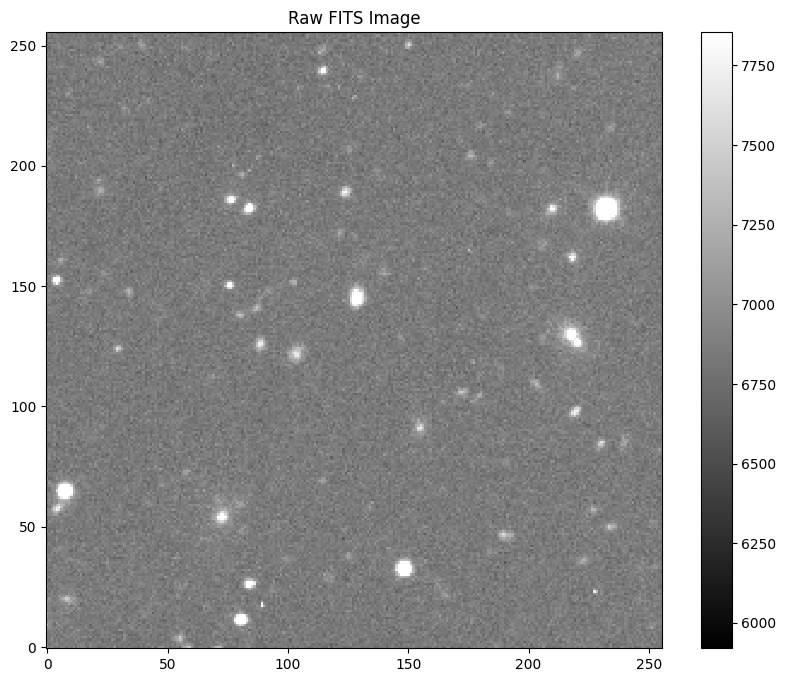

In [3]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.title("Raw FITS Image")
plt.show()


## 3. Background estimation and subtraction


In [5]:
# Estimate background
bkg = sep.Background(data)
data_sub = data - bkg


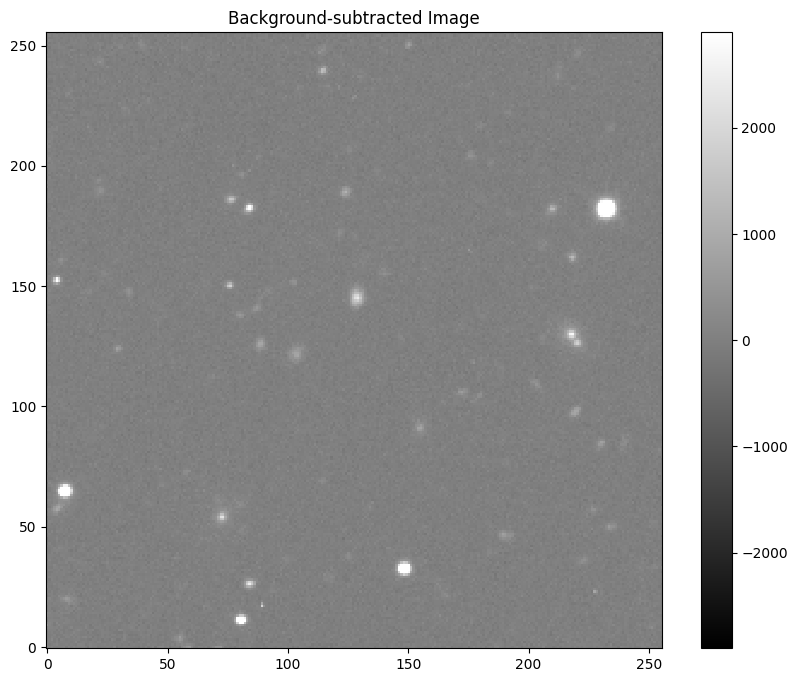

In [8]:
# Display background-subtracted image
plt.imshow(data_sub, interpolation='nearest', cmap='gray', vmin=-3*s, vmax=3*s, origin='lower')
plt.colorbar()
plt.title("Background-subtracted Image")
plt.show()


## 4. Object detection

Detect objects that are 1.5σ above the background.


In [9]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)
print(f"Number of objects detected: {len(objects)}")


Number of objects detected: 68


## 5. Plot detected objects

We overlay ellipses using each object's `x`, `y`, `a`, `b`, and `theta` values.


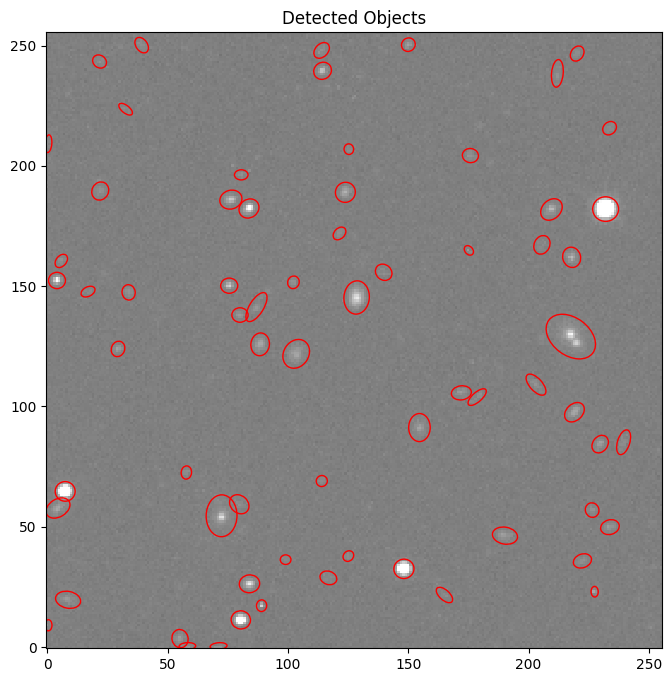

In [10]:
plt.imshow(data_sub, interpolation='nearest', cmap='gray', vmin=-3*s, vmax=3*s, origin='lower')
for obj in objects:
    e = Ellipse(xy=(obj['x'], obj['y']),
                width=6*obj['a'],
                height=6*obj['b'],
                angle=obj['theta']*180./np.pi,
                edgecolor='red', facecolor='none')
    plt.gca().add_patch(e)
plt.title("Detected Objects")
plt.show()


## 6. Aperture photometry

Measure fluxes for each detected object within a circular aperture of radius = 3 pixels.


In [11]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0, err=bkg.globalrms, gain=1.0)

# Print the first 10 fluxes
for i in range(min(10, len(flux))):
    print(f"Object {i}: Flux = {flux[i]:.2f}, Error = {fluxerr[i]:.2f}, Flag = {flag[i]}")


Object 0: Flux = 2249.16, Error = 291.03, Flag = 16
Object 1: Flux = 3092.22, Error = 291.59, Flag = 16
Object 2: Flux = 5949.87, Error = 356.56, Flag = 0
Object 3: Flux = 1851.43, Error = 295.03, Flag = 16
Object 4: Flux = 72736.39, Error = 440.17, Flag = 0
Object 5: Flux = 3860.76, Error = 352.16, Flag = 0
Object 6: Flux = 6418.91, Error = 357.46, Flag = 0
Object 7: Flux = 2210.71, Error = 350.79, Flag = 0
Object 8: Flux = 2741.61, Error = 352.28, Flag = 0
Object 9: Flux = 20916.88, Error = 376.97, Flag = 0


## Notes

- This notebook now **follows the SEP tutorial exactly**, using the official example FITS file.  
- You can experiment with:
  - Detection threshold (`1.5` in `sep.extract`)  
  - Aperture radius in `sep.sum_circle`  
  - Background box/filter sizes using `sep.Background(data, bw=64, bh=64, fw=3, fh=3)`  
- Workflow:
  1. Load FITS image →  
  2. Estimate background →  
  3. Subtract background →  
  4. Detect objects →  
  5. Measure fluxes


## 7. Plot detected objects with labels


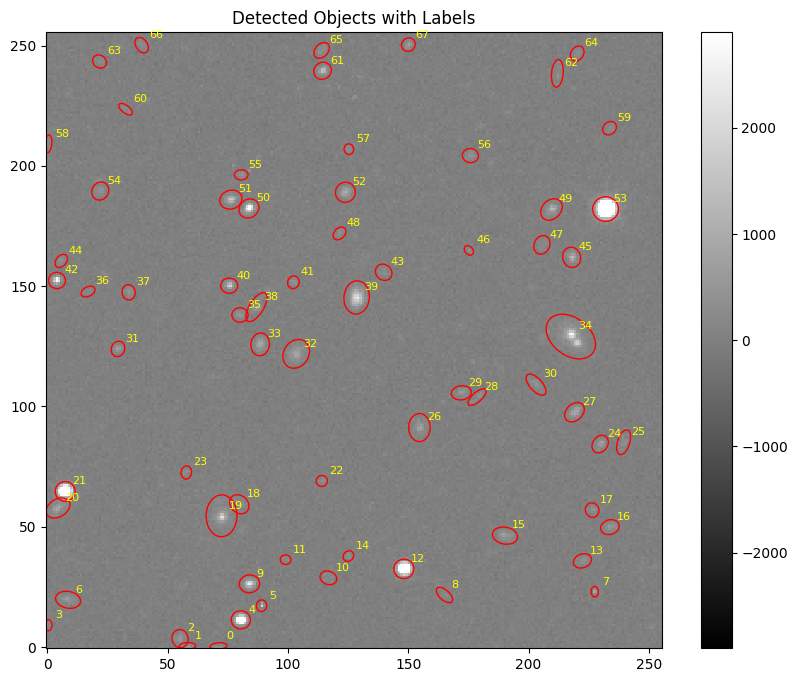

In [14]:
plt.imshow(data_sub, interpolation='nearest', cmap='gray', vmin=-3*s, vmax=3*s, origin='lower')

for i, obj in enumerate(objects):
    # Draw an ellipse for each object
    e = Ellipse(xy=(obj['x'], obj['y']),
                width=6*obj['a'],
                height=6*obj['b'],
                angle=obj['theta']*180./np.pi,
                edgecolor='red', facecolor='none')
    plt.gca().add_patch(e)
    
    # Add a label (object number) next to the object
    plt.text(obj['x']+3, obj['y']+3, str(i), color='yellow', fontsize=8)

plt.title("Detected Objects with Labels")
plt.colorbar()
plt.show()


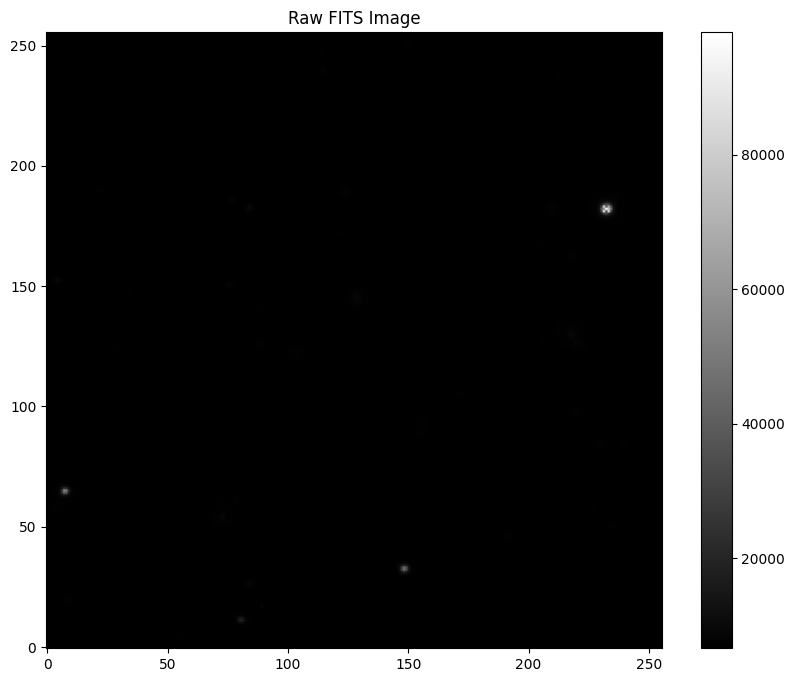

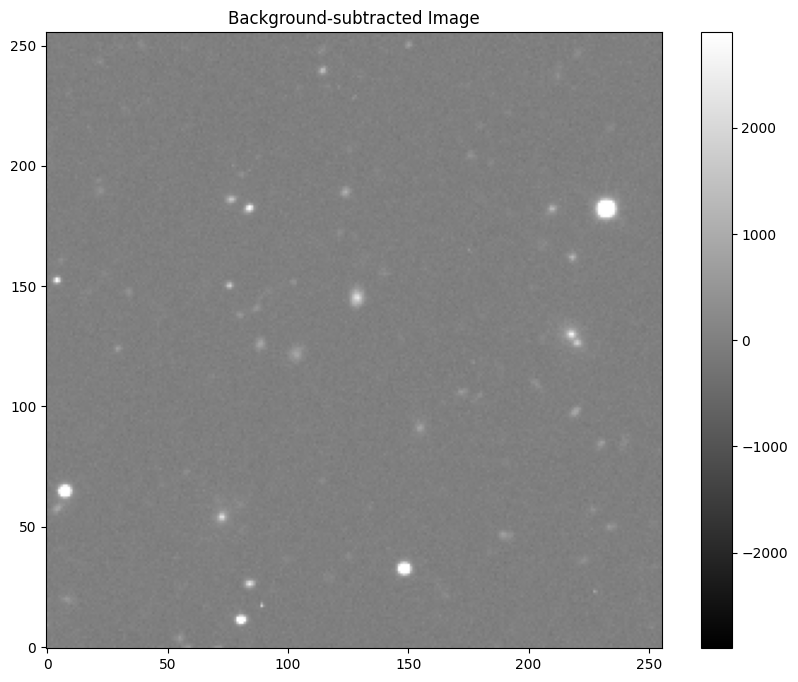

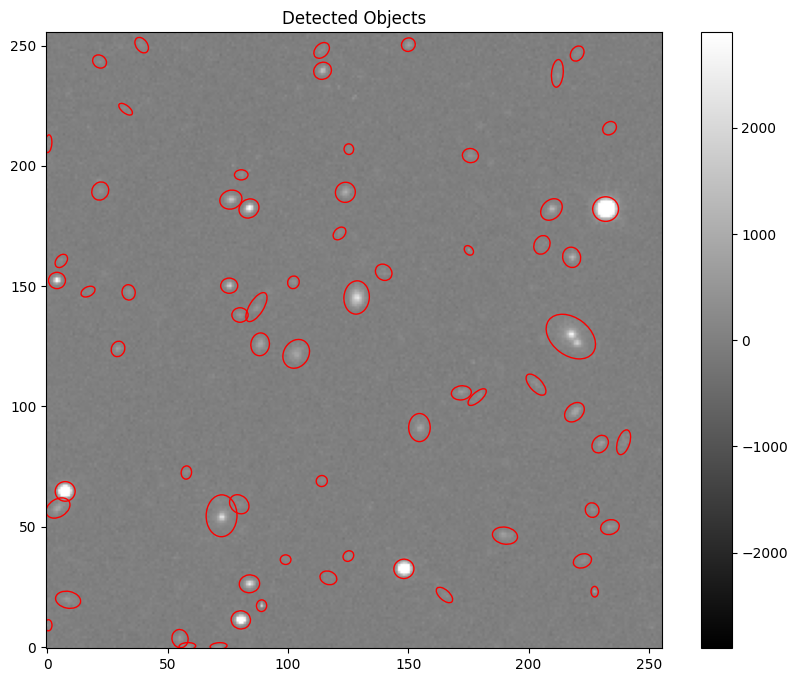

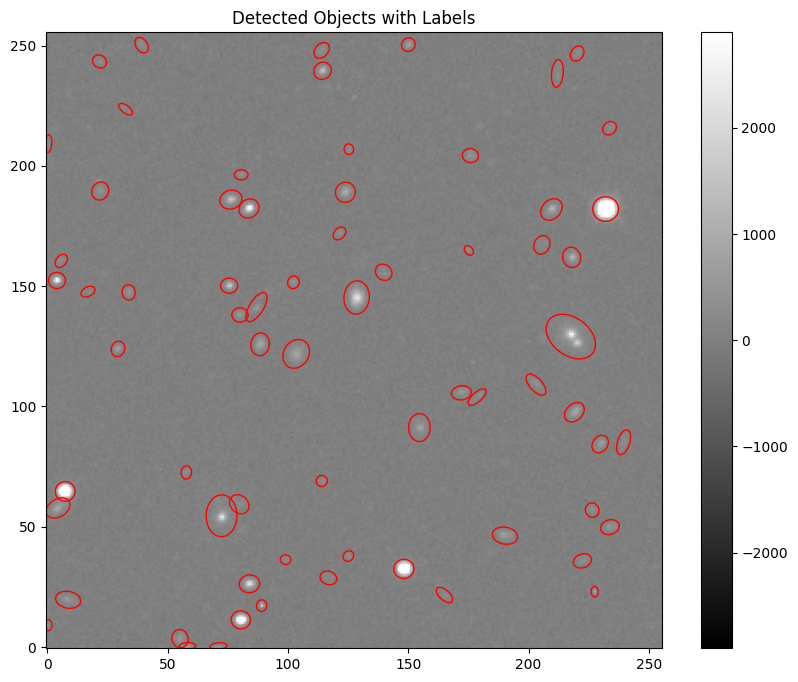

In [15]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np

# List of figures to generate: (title, save filename, plotting function)
figures = [
    ("Raw FITS Image", '/Users/cielovera/Downloads/fig1_raw_image.png', lambda: plt.imshow(data, cmap='gray', origin='lower')),
    ("Background-subtracted Image", '/Users/cielovera/Downloads/fig2_background_subtracted.png', 
        lambda: plt.imshow(data_sub, cmap='gray', origin='lower', vmin=-3*np.std(data), vmax=3*np.std(data))),
    ("Detected Objects", '/Users/cielovera/Downloads/fig3_detected_objects.png', 
        lambda: [plt.imshow(data_sub, cmap='gray', origin='lower', vmin=-3*np.std(data), vmax=3*np.std(data)),
                 [plt.gca().add_patch(Ellipse(xy=(obj['x'], obj['y']),
                                              width=6*obj['a'], height=6*obj['b'], angle=obj['theta']*180./np.pi,
                                              edgecolor='red', facecolor='none')) for obj in objects]]),
    ("Detected Objects with Labels", '/Users/cielovera/Downloads/fig4_labeled_objects.png', 
        lambda: [plt.imshow(data_sub, cmap='gray', origin='lower', vmin=-3*np.std(data), vmax=3*np.std(data)),
                 [plt.gca().add_patch(Ellipse(xy=(obj['x'], obj['y']),
                                              width=6*obj['a'], height=6*obj['b'], angle=obj['theta']*180./np.pi,
                                              edgecolor='red', facecolor='none')) or
                  plt.text(obj['x']+3, obj['y']+3, str(i), color='yellow', fontsize=8) 
                  for i, obj in enumerate(objects)]]),
]

# Loop over the figures and save each
for title, filename, plot_func in figures:
    plt.figure()
    plot_func()  # run the plotting lambda
    plt.colorbar()
    plt.title(title)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
